<a href="https://colab.research.google.com/github/sahar-mariam/ML-for-WESAD/blob/main/wesad_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WESAD Stress Detection — Minimal Calibration Personalization Study
*"How much subject-specific calibration data does a stress detector need before it works well on a new person?"*

1. **Calibration curve** — accuracy vs amount of calibration data (K = 0, 1, 5, 10, 20, 50 windows)
2. **Cross-modal coherence features** — ECG-EDA coupling features
3. **Subject-independent evaluation** — rigorous LOSO baseline
4. **Practical finding** — identifies the minimum calibration needed for deployment

**Dataset:** WESAD (Schmidt et al., 2018) | **Signals:** ECG + EDA (chest, 700Hz)

---


## Install Dependencies

In [ ]:
!pip install neurokit2==0.2.7 xgboost==1.6.2 scikit-learn==1.3.2 pandas numpy matplotlib seaborn scipy tqdm statsmodels -q

## Imports & Configuration

In [ ]:
import os, gc, glob, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk

from pathlib import Path
from tqdm import tqdm
from scipy.stats import kruskal, pearsonr, spearmanr
from scipy.signal import coherence
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    cohen_kappa_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
from matplotlib.patches import Patch
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')

BASE_DIR = Path("/Users/bsaharmariam/Desktop/wesad_stress_detection")

DATASET_PATH  = BASE_DIR / "data" / "WESAD"
PROCESSED_DIR = BASE_DIR / "outputs" / "processed"
FEATURES_DIR  = BASE_DIR / "outputs" / "features"
FIGURES_DIR   = BASE_DIR / "outputs" / "figures"
RESULTS_DIR   = BASE_DIR / "outputs" / "results"

for d in [PROCESSED_DIR, FEATURES_DIR, FIGURES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ALL_SUBJECTS  = ['S2','S3','S4','S5','S6','S7','S8','S9',
                 'S10','S11','S13','S14','S15','S16','S17']
SAMPLING_RATE = 700
WINDOW_SEC    = 30
OVERLAP_SEC   = 10
LABEL_MAP     = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
VALID_LABELS  = [1, 2, 3]

PALETTE      = {'Baseline': '#3498db', 'Stress': '#e74c3c', 'Amusement': '#2ecc71'}
MODEL_COLORS = {'RandomForest': '#8e44ad', 'SVM': '#e67e22', 'XGBoost': '#16a085'}

# Calibration K values — number of windows given to model from test subject
K_VALUES = [0, 1, 5, 10, 20, 50]

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"\n  Dataset not found at: {DATASET_PATH}"
        f"\n  Expected: data/WESAD/S2/S2.pkl ..."
    )

print(" Setup has completed.")
print(f"   Base directory      : {BASE_DIR}")
print(f"   Dataset       : {DATASET_PATH}")
print(f"   Window size   : {WINDOW_SEC}s / {OVERLAP_SEC}s overlap")
print(f"   K values      : {K_VALUES}")


/Users/bsaharmariam/Desktop/wesad_stress_detection/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


 Setup has completed.
   Base directory      : /Users/bsaharmariam/Desktop/wesad_stress_detection
   Dataset       : /Users/bsaharmariam/Desktop/wesad_stress_detection/data/WESAD
   Window size   : 30s / 10s overlap
   K values      : [0, 1, 5, 10, 20, 50]


## Signal Cleaning

In [ ]:
def clean_subject(subject):
    file_path = DATASET_PATH / subject / f"{subject}.pkl"
    save_path = PROCESSED_DIR / f"{subject}_cleaned.csv"

    if not file_path.exists():
        print(f"   {subject}: .pkl not found — skipping.")
        return None
    if save_path.exists():
        print(f"   {subject}: already processed.")
        return pd.read_csv(save_path)

    print(f"  {subject}...", end=" ", flush=True)
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest   = data["signal"]["chest"]
    ecg_raw = np.nan_to_num(chest["ECG"].flatten())
    eda_raw = np.nan_to_num(chest["EDA"].flatten())
    labels  = data["label"]
    del data; gc.collect()

    chunk = SAMPLING_RATE * 60
    ecg_out, eda_out = [], []
    for s in range(0, len(ecg_raw), chunk):
        e = min(s + chunk, len(ecg_raw))
        ecg_out.append(nk.ecg_clean(ecg_raw[s:e], sampling_rate=SAMPLING_RATE))
        eda_out.append(nk.eda_clean(eda_raw[s:e], sampling_rate=SAMPLING_RATE))
        gc.collect()

    df = pd.DataFrame({
        'ECG_Clean': np.concatenate(ecg_out),
        'EDA_Clean': np.concatenate(eda_out),
        'Label':     labels
    })
    df.to_csv(save_path, index=False)
    print(f"done ({len(df):,} samples)")
    del ecg_raw, eda_raw; gc.collect()
    return df

print("STEP 1 — SIGNAL CLEANING")
for subj in ALL_SUBJECTS:
    clean_subject(subj)
print("\n All subjects cleaned.")


STEP 1 — SIGNAL CLEANING
   S2: already processed.
   S3: already processed.
   S4: already processed.
   S5: already processed.
   S6: already processed.
   S7: already processed.
   S8: already processed.
   S9: already processed.
   S10: already processed.
   S11: already processed.
   S13: already processed.
   S14: already processed.
   S15: already processed.
   S16: already processed.
   S17: already processed.

 All subjects cleaned.


## Figure 1: Preprocessing Quality Check

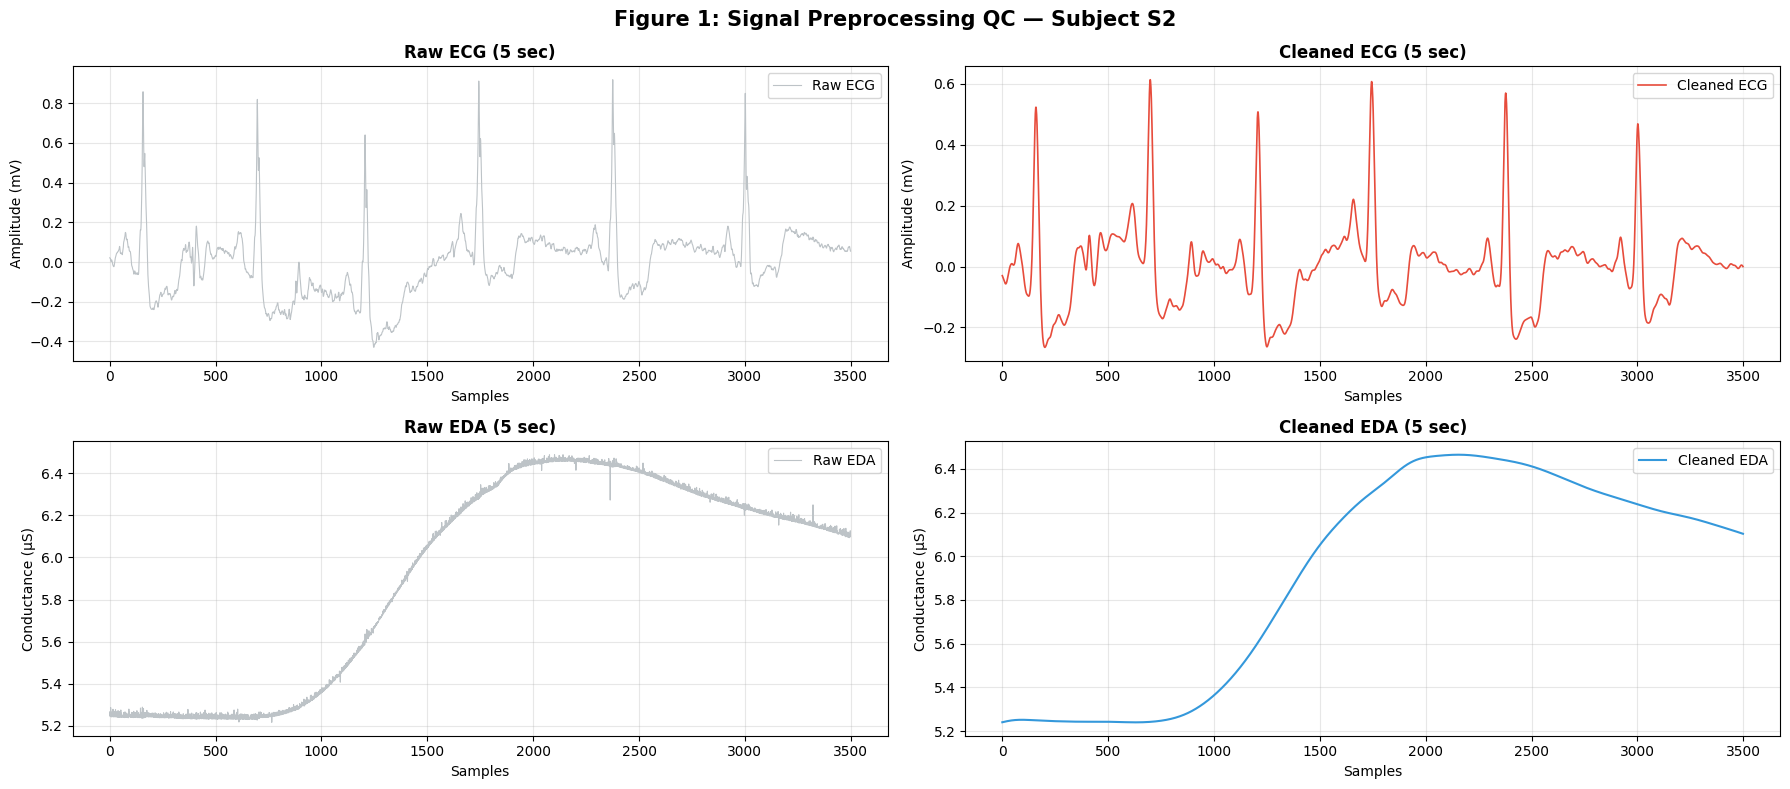

Fig1_Preprocessing_QC saved.


In [ ]:
demo_subj = next(
    (s for s in ALL_SUBJECTS if (PROCESSED_DIR / f"{s}_cleaned.csv").exists()), None
)

if demo_subj:
    with open(DATASET_PATH / demo_subj / f"{demo_subj}.pkl", "rb") as f:
        raw_data = pickle.load(f, encoding="latin1")
    ecg_raw_d = raw_data["signal"]["chest"]["ECG"].flatten()
    eda_raw_d = raw_data["signal"]["chest"]["EDA"].flatten()
    del raw_data

    df_clean_d = pd.read_csv(PROCESSED_DIR / f"{demo_subj}_cleaned.csv")
    plot_n = 5 * SAMPLING_RATE

    fig, axes = plt.subplots(2, 2, figsize=(18, 8))
    fig.suptitle(f'Figure 1: Signal Preprocessing QC — Subject {demo_subj}',
                 fontsize=15, fontweight='bold')

    axes[0,0].plot(ecg_raw_d[:plot_n], color='#bdc3c7', lw=0.8, label='Raw ECG')
    axes[0,0].set_title('Raw ECG (5 sec)', fontweight='bold')
    axes[0,0].set_ylabel('Amplitude (mV)'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(df_clean_d['ECG_Clean'].values[:plot_n], color='#e74c3c', lw=1.2, label='Cleaned ECG')
    axes[0,1].set_title('Cleaned ECG (5 sec)', fontweight='bold')
    axes[0,1].set_ylabel('Amplitude (mV)'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(eda_raw_d[:plot_n], color='#bdc3c7', lw=0.8, label='Raw EDA')
    axes[1,0].set_title('Raw EDA (5 sec)', fontweight='bold')
    axes[1,0].set_ylabel('Conductance (μS)'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(df_clean_d['EDA_Clean'].values[:plot_n], color='#3498db', lw=1.5, label='Cleaned EDA')
    axes[1,1].set_title('Cleaned EDA (5 sec)', fontweight='bold')
    axes[1,1].set_ylabel('Conductance (μS)'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    for ax in axes.flat: ax.set_xlabel('Samples')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'Fig1_Preprocessing_QC.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig1_Preprocessing_QC saved.")
    del ecg_raw_d, eda_raw_d, df_clean_d


## Figure 2: EDA Decomposition During Stress

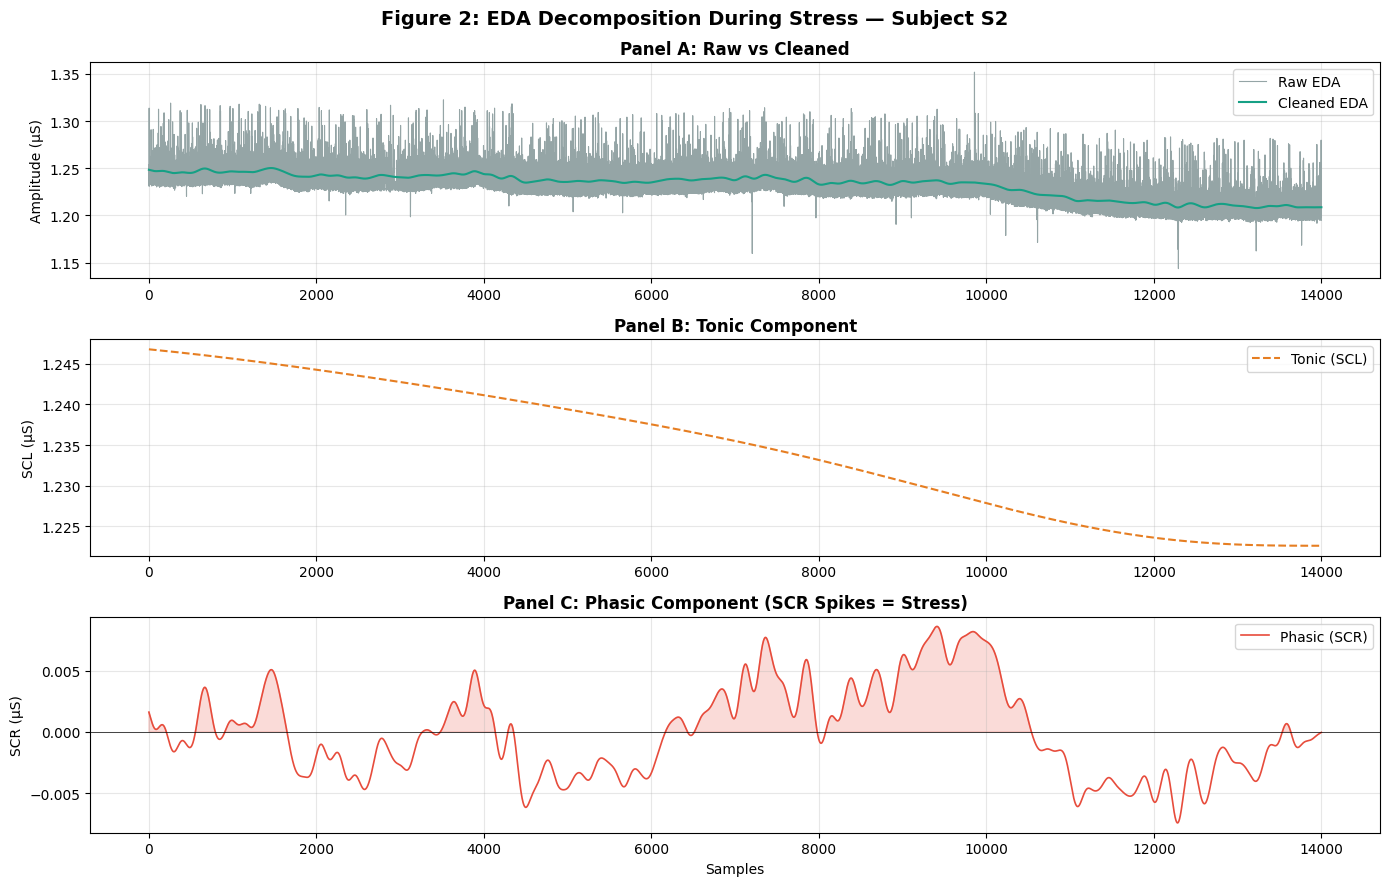

 Fig2_EDA_Decomposition saved.


In [ ]:
if demo_subj:
    with open(DATASET_PATH / demo_subj / f"{demo_subj}.pkl", "rb") as f:
        raw_data = pickle.load(f, encoding="latin1")
    eda_chest   = raw_data["signal"]["chest"]["EDA"].flatten()
    labels_demo = raw_data["label"]
    del raw_data

    stress_idx = np.where(labels_demo == 2)[0]
    if len(stress_idx) > 14000:
        seg = eda_chest[stress_idx[5000]: stress_idx[5000] + 14000]
        signals, _ = nk.eda_process(seg, sampling_rate=SAMPLING_RATE)

        fig, axes = plt.subplots(3, 1, figsize=(14, 9))
        fig.suptitle(f'Figure 2: EDA Decomposition During Stress — Subject {demo_subj}',
                     fontsize=14, fontweight='bold')

        axes[0].plot(signals["EDA_Raw"],   color='#95a5a6', lw=0.8, label='Raw EDA')
        axes[0].plot(signals["EDA_Clean"], color='#16a085', lw=1.5, label='Cleaned EDA')
        axes[0].set_title('Panel A: Raw vs Cleaned', fontweight='bold')
        axes[0].legend(); axes[0].set_ylabel('Amplitude (μS)'); axes[0].grid(alpha=0.3)

        axes[1].plot(signals["EDA_Tonic"], color='#e67e22', lw=1.5,
                     linestyle='--', label='Tonic (SCL)')
        axes[1].set_title('Panel B: Tonic Component', fontweight='bold')
        axes[1].legend(); axes[1].set_ylabel('SCL (μS)'); axes[1].grid(alpha=0.3)

        axes[2].plot(signals["EDA_Phasic"], color='#e74c3c', lw=1.2, label='Phasic (SCR)')
        axes[2].axhline(0, color='black', lw=0.5)
        axes[2].fill_between(range(len(signals["EDA_Phasic"])),
                              signals["EDA_Phasic"], 0,
                              where=(signals["EDA_Phasic"] > 0),
                              alpha=0.2, color='#e74c3c')
        axes[2].set_title('Panel C: Phasic Component (SCR Spikes = Stress)', fontweight='bold')
        axes[2].legend(); axes[2].set_ylabel('SCR (μS)')
        axes[2].set_xlabel('Samples'); axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'Fig2_EDA_Decomposition.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(" Fig2_EDA_Decomposition saved.")
    del eda_chest, labels_demo


## Feature Extraction
Extracts HRV + EDA + Cross-Modal features per 30s window.


In [ ]:
def extract_crossmodal_features(ecg_window, eda_window, hrv_metrics, eda_metrics):
    """6 cross-modal coherence features capturing ECG-EDA autonomic coupling."""
    feats = {}

    try:
        corr, _ = pearsonr(ecg_window, eda_window)
        feats['CrossModal_ECG_EDA_Pearson'] = corr
    except Exception:
        feats['CrossModal_ECG_EDA_Pearson'] = np.nan

    try:
        scorr, _ = spearmanr(ecg_window, eda_window)
        feats['CrossModal_ECG_EDA_Spearman'] = scorr
    except Exception:
        feats['CrossModal_ECG_EDA_Spearman'] = np.nan

    try:
        f, Cxy = coherence(ecg_window, eda_window, fs=SAMPLING_RATE, nperseg=512)
        lf_mask = (f >= 0.04) & (f <= 0.15)
        hf_mask = (f >= 0.15) & (f <= 0.40)
        feats['CrossModal_Coherence_LF'] = np.mean(Cxy[lf_mask]) if lf_mask.any() else np.nan
        feats['CrossModal_Coherence_HF'] = np.mean(Cxy[hf_mask]) if hf_mask.any() else np.nan
    except Exception:
        feats['CrossModal_Coherence_LF'] = np.nan
        feats['CrossModal_Coherence_HF'] = np.nan

    try:
        rmssd     = hrv_metrics.get('HRV_RMSSD', pd.Series([np.nan])).values[0]
        tonic_col = next((c for c in eda_metrics.columns if 'Tonic' in c), None)
        tonic     = eda_metrics[tonic_col].values[0] if tonic_col else np.nan
        feats['CrossModal_RMSSD_Tonic_Ratio'] = rmssd / tonic if tonic and tonic != 0 else np.nan
    except Exception:
        feats['CrossModal_RMSSD_Tonic_Ratio'] = np.nan

    try:
        feats['CrossModal_Variance_Ratio'] = np.var(ecg_window) / np.var(eda_window)             if np.var(eda_window) > 0 else np.nan
    except Exception:
        feats['CrossModal_Variance_Ratio'] = np.nan

    try:
        hf      = hrv_metrics.get('HRV_HF', pd.Series([np.nan])).values[0]
        scr_col = next((c for c in eda_metrics.columns
                        if 'SCR_Peaks_N' in c or 'SCR_Peaks' in c), None)
        scr     = eda_metrics[scr_col].values[0] if scr_col else np.nan
        feats['CrossModal_HF_SCR_Ratio'] = hf / scr if scr and scr > 0 else np.nan
    except Exception:
        feats['CrossModal_HF_SCR_Ratio'] = np.nan

    return feats


def extract_features(df, subject_id):
    """Sliding window: HRV + EDA + Cross-Modal features. 90% label purity filter."""
    win  = WINDOW_SEC * SAMPLING_RATE
    step = OVERLAP_SEC * SAMPLING_RATE
    rows = []

    if len(df) < win:
        return pd.DataFrame()

    for i in tqdm(range(0, len(df) - win, step),
                  desc=f"  {subject_id}", leave=False):
        window = df.iloc[i: i + win]
        mode_v = window['Label'].mode()
        if len(mode_v) == 0: continue
        label = mode_v.iloc[0]
        if label not in VALID_LABELS: continue

        # 90% purity filter — remove transitional windows
        purity = (window['Label'] == label).mean()
        if purity < 0.90: continue

        try:
            ecg_win = window['ECG_Clean'].values
            eda_win = window['EDA_Clean'].values

            ecg_sig, _ = nk.ecg_process(ecg_win, sampling_rate=SAMPLING_RATE)
            hrv_df     = nk.hrv(ecg_sig, sampling_rate=SAMPLING_RATE)

            eda_sig, _ = nk.eda_process(eda_win, sampling_rate=SAMPLING_RATE)
            eda_df     = nk.eda_analyze(eda_sig, sampling_rate=SAMPLING_RATE)

            cm_feats = extract_crossmodal_features(ecg_win, eda_win, hrv_df, eda_df)
            cm_df    = pd.DataFrame([cm_feats])

            row = pd.concat([hrv_df, eda_df, cm_df], axis=1)
            row['label']        = label
            row['subject']      = subject_id
            row['window_index'] = i
            rows.append(row)
        except Exception:
            continue

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print("STEP 2 — FEATURE EXTRACTION")

for subj in ALL_SUBJECTS:
    feat_path = FEATURES_DIR / f"{subj}_features.csv"
    if feat_path.exists():
        print(f"   {subj}: features exist — skipping."); continue
    csv_path = PROCESSED_DIR / f"{subj}_cleaned.csv"
    if not csv_path.exists():
        print(f"   {subj}: no cleaned CSV."); continue
    feats = extract_features(pd.read_csv(csv_path), subj)
    if feats.empty:
        print(f"   {subj}: no features extracted."); continue
    feats.to_csv(feat_path, index=False)
    print(f"   {subj}: {len(feats)} windows saved.")
    gc.collect()

print("\n Feature extraction is completed.")


STEP 2 — FEATURE EXTRACTION
   S2: features exist — skipping.
   S3: features exist — skipping.
   S4: features exist — skipping.
   S5: features exist — skipping.
   S6: features exist — skipping.
   S7: features exist — skipping.
   S8: features exist — skipping.
   S9: features exist — skipping.
   S10: features exist — skipping.
   S11: features exist — skipping.
   S13: features exist — skipping.
   S14: features exist — skipping.
   S15: features exist — skipping.
   S16: features exist — skipping.
   S17: features exist — skipping.

 Feature extraction is completed.


## Load Master Feature Matrix

In [ ]:
feat_files = sorted(FEATURES_DIR.glob("S*_features.csv"))
if not feat_files:
    raise FileNotFoundError("No feature files found. Run Cell 7 first.")

df_master = pd.concat([pd.read_csv(f) for f in feat_files], ignore_index=True)
df_master.dropna(axis=1, how='all', inplace=True)
df_master.replace([np.inf, -np.inf], np.nan, inplace=True)
df_master['Condition'] = df_master['label'].map(LABEL_MAP)

print(f"Master matrix shape  : {df_master.shape}")
print(f"Subjects loaded      : {sorted(df_master['subject'].unique())}")
print(f"\nLabel distribution:")
print(df_master['label'].value_counts())
print(f"\nClass balance:")
print((df_master['label'].value_counts(normalize=True)*100).round(1))
print(f"\nCross-modal features found:")
for c in df_master.columns:
    if 'CrossModal' in c: print(f"  {c}")


Master matrix shape  : (3212, 83)
Subjects loaded      : ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Label distribution:
label
1    1726
2     963
3     523
Name: count, dtype: int64

Class balance:
label
1    53.7
2    30.0
3    16.3
Name: proportion, dtype: float64

Cross-modal features found:
  CrossModal_ECG_EDA_Pearson
  CrossModal_ECG_EDA_Spearman
  CrossModal_RMSSD_Tonic_Ratio
  CrossModal_Variance_Ratio
  CrossModal_HF_SCR_Ratio


## Add Temporal Context Features
Appends previous window features to current window.

In [ ]:
def add_temporal_context(df, n_lags=1):
    """Append previous window features per subject. Preserves temporal order."""
    all_subjects = []
    feat_cols = [c for c in df.columns
                 if c not in ['label','subject','Condition','window_index']]

    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj].copy()
        if 'window_index' in subj_df.columns:
            subj_df = subj_df.sort_values('window_index').reset_index(drop=True)

        for lag in range(1, n_lags + 1):
            lag_df = subj_df[feat_cols].shift(lag)
            lag_df.columns = [f"{c}_lag{lag}" for c in feat_cols]
            subj_df = pd.concat([subj_df, lag_df], axis=1)

        subj_df = subj_df.iloc[n_lags:].reset_index(drop=True)
        all_subjects.append(subj_df)

    return pd.concat(all_subjects, ignore_index=True)

print("Adding temporal context (lag-1)...")
df_temporal = add_temporal_context(df_master, n_lags=1)
print(f"Windows before lag : {len(df_master)}")
print(f"Windows after lag  : {len(df_temporal)}")
print(f"Lag features added : {len([c for c in df_temporal.columns if '_lag1' in c])}")


Adding temporal context (lag-1)...
Windows before lag : 3212
Windows after lag  : 3197
Lag features added : 79


## Figures 3–5: Exploratory Data Analysis

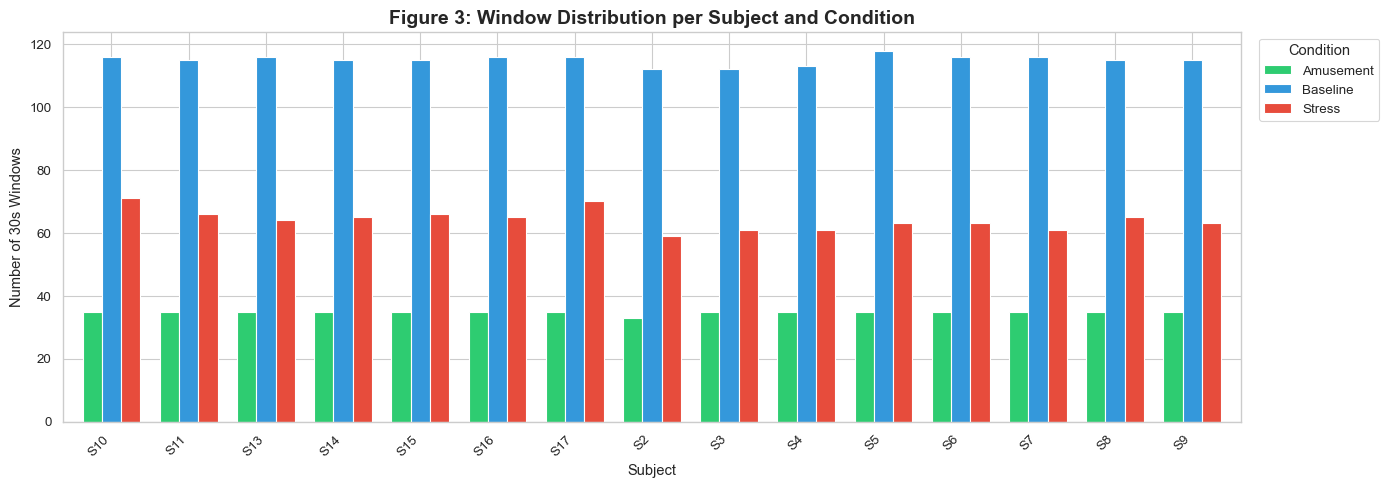

 Fig3_Label_Distribution saved.


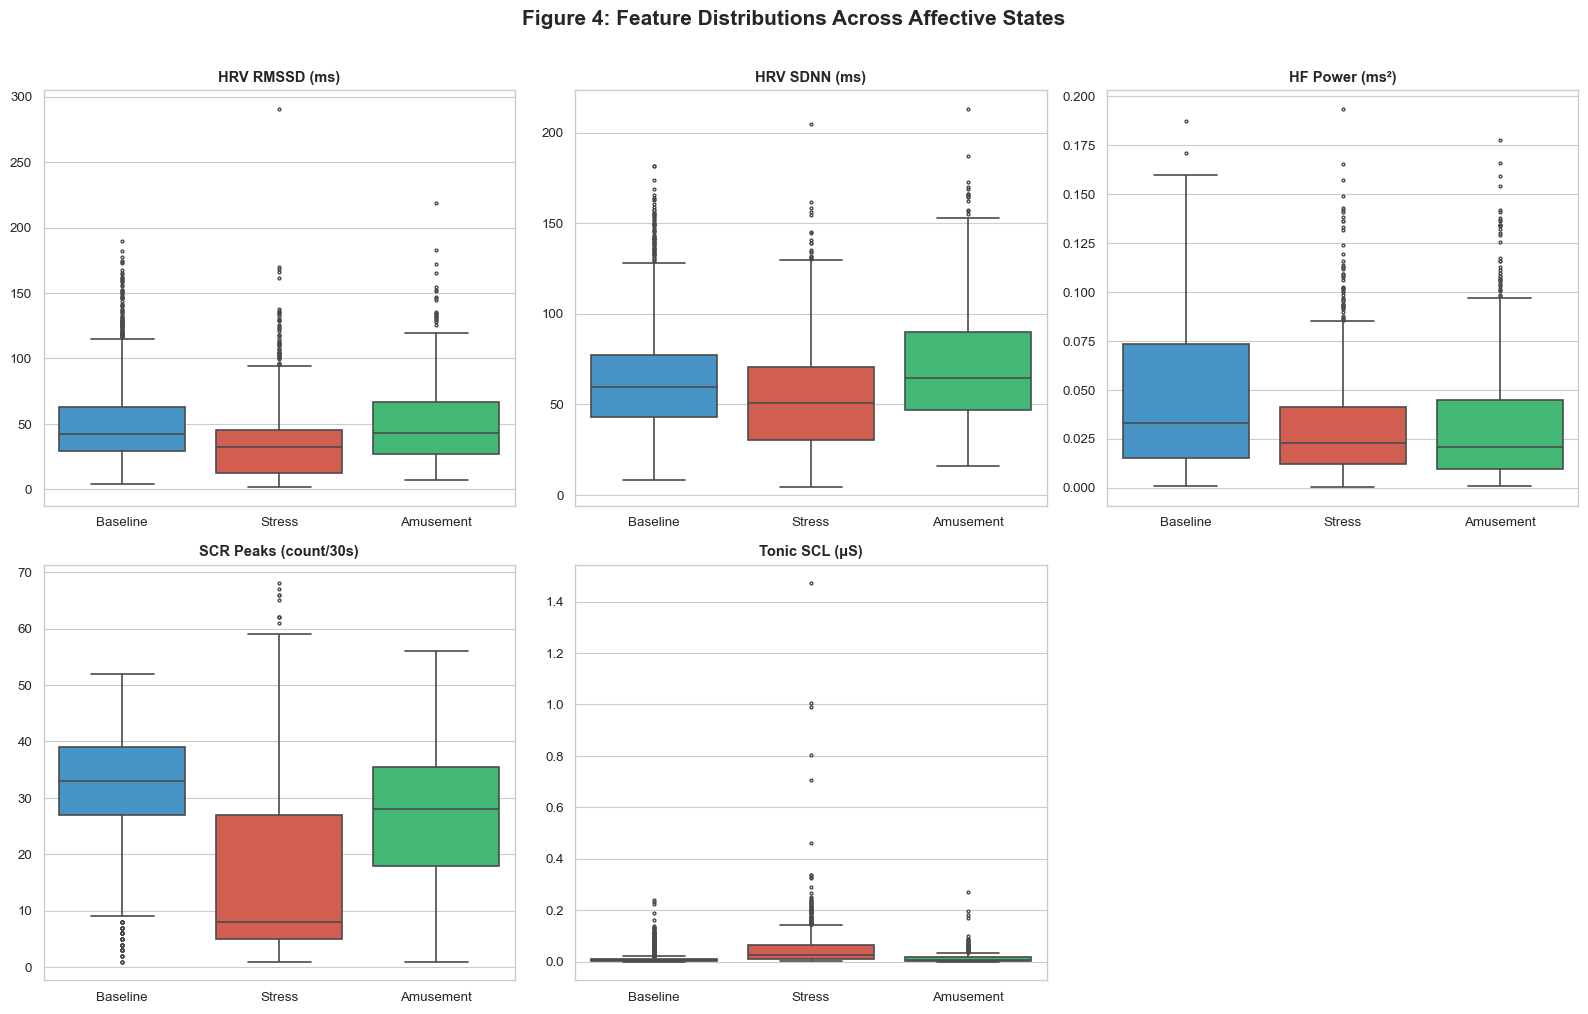

Fig4_Feature_Boxplots saved.


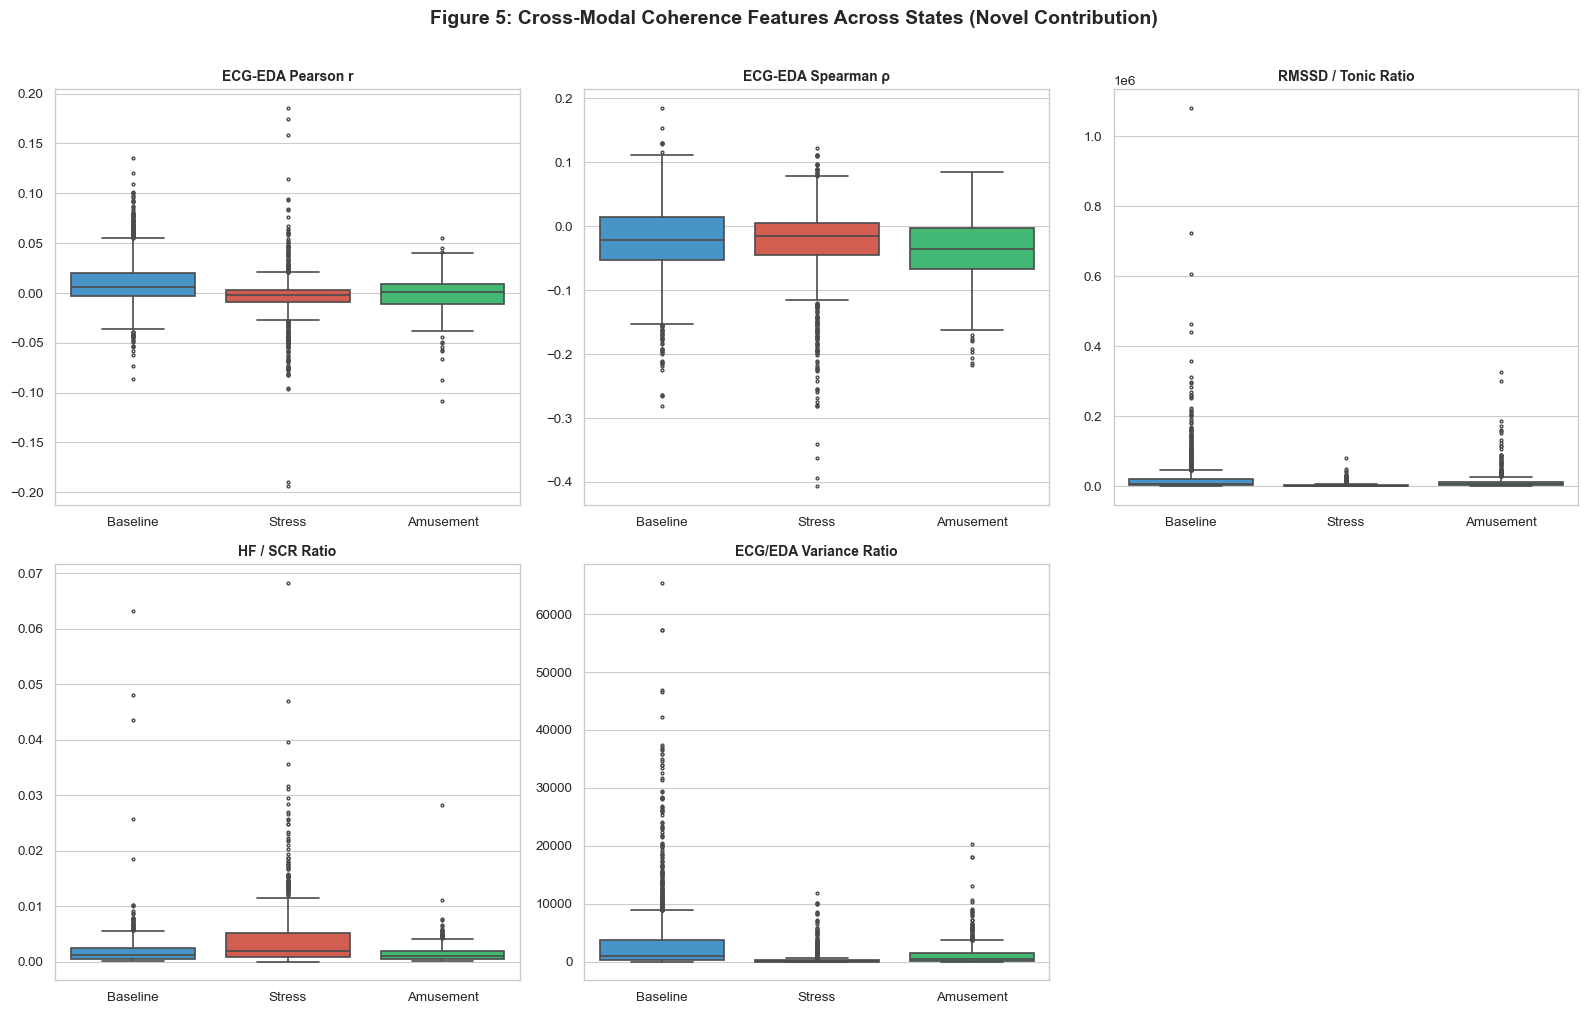

Fig5_CrossModal_Boxplots saved.


In [ ]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Figure 3: Label distribution per subject
fig, ax = plt.subplots(figsize=(14, 5))
counts = df_master.groupby(['subject','Condition']).size().unstack(fill_value=0)
counts.plot(kind='bar', ax=ax,
            color=[PALETTE[c] for c in counts.columns],
            edgecolor='white', width=0.75)
ax.set_title('Figure 3: Window Distribution per Subject and Condition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Subject'); ax.set_ylabel('Number of 30s Windows')
ax.legend(title='Condition', bbox_to_anchor=(1.01,1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig3_Label_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Fig3_Label_Distribution saved.")

# Figure 4: Key feature boxplots
key_features = {'HRV_RMSSD': 'HRV RMSSD (ms)', 'HRV_SDNN': 'HRV SDNN (ms)',
                'HRV_LF':    'LF Power (ms²)',  'HRV_HF':   'HF Power (ms²)'}
eda_col   = next((c for c in df_master.columns if 'SCR_Peaks_N' in c), None)
tonic_col = next((c for c in df_master.columns if 'Tonic' in c), None)
if eda_col:   key_features[eda_col]   = 'SCR Peaks (count/30s)'
if tonic_col: key_features[tonic_col] = 'Tonic SCL (μS)'

valid_feats = {k: v for k, v in key_features.items() if k in df_master.columns}
ncols = 3; nrows = (len(valid_feats) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
axes = axes.flatten()
for idx, (feat, label) in enumerate(valid_feats.items()):
    sub_df = df_master[['Condition', feat]].dropna()
    sns.boxplot(x='Condition', y=feat, data=sub_df, ax=axes[idx],
                palette=PALETTE, order=['Baseline','Stress','Amusement'],
                linewidth=1.2, fliersize=2)
    axes[idx].set_title(label, fontweight='bold')
    axes[idx].set_xlabel(''); axes[idx].set_ylabel('')
for j in range(idx+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Figure 4: Feature Distributions Across Affective States',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig4_Feature_Boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig4_Feature_Boxplots saved.")

# Figure 5: Cross-modal feature boxplots
cm_labels = {
    'CrossModal_ECG_EDA_Pearson':   'ECG-EDA Pearson r',
    'CrossModal_ECG_EDA_Spearman':  'ECG-EDA Spearman ρ',
    'CrossModal_Coherence_LF':      'LF Band Coherence',
    'CrossModal_Coherence_HF':      'HF Band Coherence',
    'CrossModal_RMSSD_Tonic_Ratio': 'RMSSD / Tonic Ratio',
    'CrossModal_HF_SCR_Ratio':      'HF / SCR Ratio',
    'CrossModal_Variance_Ratio':    'ECG/EDA Variance Ratio'
}
valid_cm = {k: v for k, v in cm_labels.items() if k in df_master.columns}
if valid_cm:
    ncols = 3; nrows = (len(valid_cm) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
    axes = axes.flatten()
    for idx, (feat, label) in enumerate(valid_cm.items()):
        sub_df = df_master[['Condition', feat]].dropna()
        if sub_df.empty or sub_df[feat].nunique() < 2:
            axes[idx].set_visible(False); continue
        sns.boxplot(x='Condition', y=feat, data=sub_df, ax=axes[idx],
                    palette=PALETTE, order=['Baseline','Stress','Amusement'],
                    linewidth=1.2, fliersize=2)
        axes[idx].set_title(label, fontweight='bold', fontsize=10)
        axes[idx].set_xlabel(''); axes[idx].set_ylabel('')
    for j in range(idx+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Figure 5: Cross-Modal Coherence Features Across States (Novel Contribution)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'Fig5_CrossModal_Boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig5_CrossModal_Boxplots saved.")


## Statistical Significance Tests (Kruskal-Wallis)

Features tested     : 79
Significant p<0.05  : 75

By type:
{'CrossModal': 5, 'EDA': 3, 'HRV': 67}

Top 15 features:
                     Feature  H_statistic       p_value       Type
                   HRV_MinNN     1338.849 1.873631e-291        HRV
                 HRV_Prc20NN     1251.625 1.633567e-272        HRV
                  HRV_MeanNN     1180.905 3.713068e-257        HRV
                HRV_MedianNN     1178.403 1.296988e-256        HRV
                 HRV_Prc80NN     1054.812 8.922538e-230        HRV
CrossModal_RMSSD_Tonic_Ratio     1037.054 6.406056e-226 CrossModal
                   HRV_MaxNN      835.123 4.522962e-182        HRV
   CrossModal_Variance_Ratio      822.447 2.558221e-179 CrossModal
    SCR_Peaks_Amplitude_Mean      820.446 6.956279e-179        EDA
                EDA_Tonic_SD      765.964 4.709880e-167        EDA
                 SCR_Peaks_N      708.514 1.406500e-154        EDA
                 HRV_FuzzyEn      615.475 2.245427e-134        HRV
            

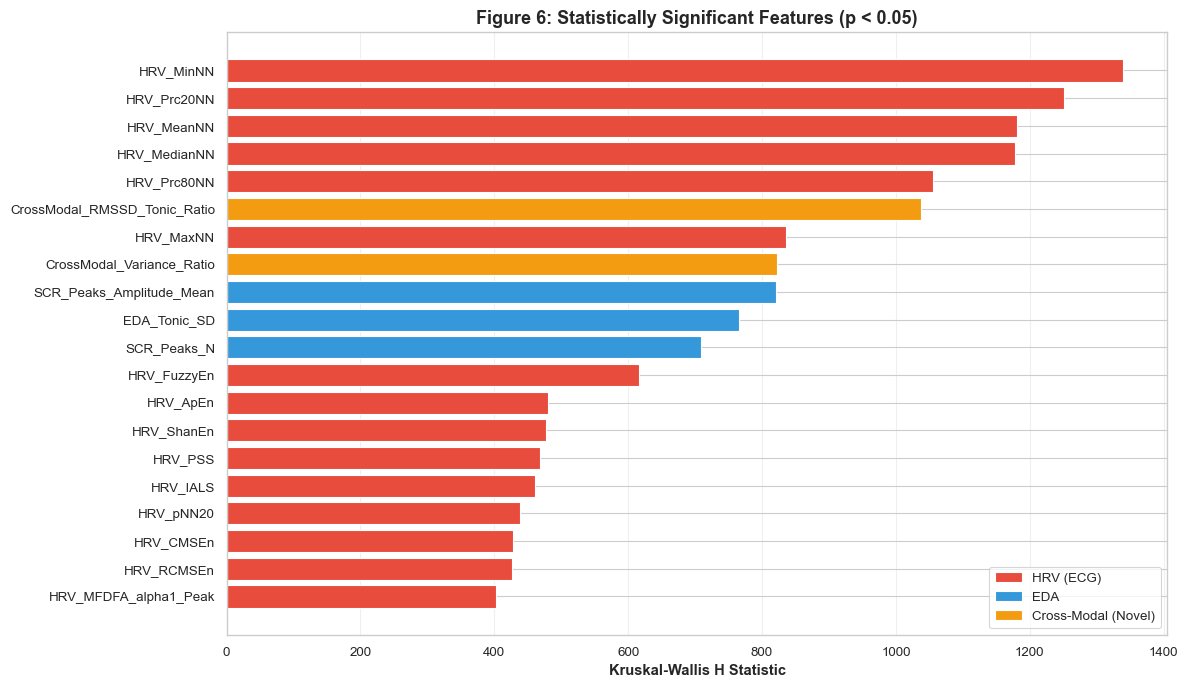

Fig6_Statistical_Significance saved.


In [ ]:
num_cols = [c for c in df_master.select_dtypes(include=np.number).columns
            if c not in ['label','window_index']]
stat_results = []

for col in num_cols:
    groups = [df_master[df_master['label']==lbl][col].dropna().values
              for lbl in VALID_LABELS]
    if all(len(g) > 5 for g in groups):
        try:
            H, p = kruskal(*groups)
            stat_results.append({
                'Feature': col, 'H_statistic': round(H,3), 'p_value': p,
                'Type': 'CrossModal' if 'CrossModal' in col else
                        'HRV' if 'HRV' in col else 'EDA'
            })
        except Exception: pass

stat_df = pd.DataFrame(stat_results).sort_values('p_value')
stat_df['Significant'] = stat_df['p_value'] < 0.05
stat_df.to_csv(RESULTS_DIR / 'Kruskal_Wallis_Results.csv', index=False)

print(f"Features tested     : {len(stat_df)}")
print(f"Significant p<0.05  : {stat_df['Significant'].sum()}")
print(f"\nBy type:")
print(stat_df[stat_df['Significant']].groupby('Type').size().to_dict())
print(f"\nTop 15 features:")
print(stat_df.head(15)[['Feature','H_statistic','p_value','Type']].to_string(index=False))

# Figure 6: Significant features bar chart
top_sig = stat_df[stat_df['Significant']].head(20).copy()
top_sig['H_statistic'] = top_sig['H_statistic'].astype(float)
type_colors = {'HRV': '#e74c3c', 'EDA': '#3498db', 'CrossModal': '#f39c12'}

if not top_sig.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    bar_colors = [type_colors.get(t, '#95a5a6') for t in top_sig['Type']]
    ax.barh(top_sig['Feature'], top_sig['H_statistic'],
            color=bar_colors, edgecolor='white')
    ax.set_xlabel('Kruskal-Wallis H Statistic', fontweight='bold')
    ax.set_title('Figure 6: Statistically Significant Features (p < 0.05)',
                 fontsize=13, fontweight='bold')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
    ax.legend(handles=[
        Patch(facecolor='#e74c3c', label='HRV (ECG)'),
        Patch(facecolor='#3498db', label='EDA'),
        Patch(facecolor='#f39c12', label='Cross-Modal (Novel)')
    ], loc='lower right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'Fig6_Statistical_Significance.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig6_Statistical_Significance saved.")


## Feature Preparation + Subject Normalization

In [ ]:
# ── Per-subject normalization ─────────────────────────────────
# Removes individual physiological baseline differences
# Forces model to learn relative changes, not absolute values
def normalize_per_subject(df):
    df_norm   = df.copy()
    feat_cols = [c for c in df.columns
                 if c not in ['label','subject','Condition','window_index']]
    for subj in df['subject'].unique():
        mask = df['subject'] == subj
        for col in feat_cols:
            if col not in df.columns: continue
            mu  = df.loc[mask, col].mean()
            std = df.loc[mask, col].std()
            df_norm.loc[mask, col] = (df.loc[mask, col] - mu) / std                 if std > 0 else 0.0
    return df_norm

print("Applying per-subject normalization...")
df_master  = normalize_per_subject(df_master)
df_temporal = normalize_per_subject(df_temporal)
print(" Per-subject normalization applied.")

# ── Feature set definitions ───────────────────────────────────
meta_cols     = ['label','subject','Condition','window_index']
ecg_feat_cols = [c for c in df_master.columns
                 if 'HRV' in c.upper() and c not in meta_cols]
eda_feat_cols = [c for c in df_master.columns
                 if any(k in c.upper() for k in ['SCR','SCL','EDA','PHASIC','TONIC'])
                 and c not in meta_cols + ['ECG_Clean','EDA_Clean']]
cm_feat_cols  = [c for c in df_master.columns if 'CrossModal' in c]
fusion_cols   = list(set(ecg_feat_cols + eda_feat_cols))
fusion_cm     = list(set(ecg_feat_cols + eda_feat_cols + cm_feat_cols))
fusion_full   = [c for c in df_temporal.columns if c not in meta_cols]

MODALITIES = {
    'ECG_Only':   (df_master,   ecg_feat_cols),
    'EDA_Only':   (df_master,   eda_feat_cols),
    'Fusion':     (df_master,   fusion_cols),
    'Fusion_Full':(df_temporal, fusion_full),
}

print("\nFeature sets:")
for name, (df_use, cols) in MODALITIES.items():
    avail = [c for c in cols if c in df_use.columns]
    print(f"  {name:15s}: {len(avail):3d} features | {len(df_use):4d} windows")

# Calibration uses Fusion_Full — best feature set
CALIB_DF, CALIB_COLS_RAW = MODALITIES['Fusion_Full']
print(f"\nCalibration feature set: Fusion_Full")
print(f"K values to test: {K_VALUES}")

def prepare_df(df, feature_cols):
    """Clean features: drop empty cols, fill NaN, remove unstable."""
    avail = [c for c in feature_cols if c in df.columns]
    sub   = df[avail + ['label','subject']].copy()
    sub   = sub.dropna(axis=1, how='all')
    sub.replace([np.inf,-np.inf], np.nan, inplace=True)
    keep  = sub.isnull().mean() < 0.6
    sub   = sub.loc[:, keep | sub.columns.isin(['label','subject'])]
    num   = sub.select_dtypes(include=np.number).columns
    sub[num] = sub[num].fillna(sub[num].median())
    return sub, [c for c in sub.columns if c not in ['label','subject']]


Applying per-subject normalization...
 Per-subject normalization applied.

Feature sets:
  ECG_Only       :  71 features | 3212 windows
  EDA_Only       :   7 features | 3212 windows
  Fusion         :  78 features | 3212 windows
  Fusion_Full    : 158 features | 3197 windows

Calibration feature set: Fusion_Full
K values to test: [0, 1, 5, 10, 20, 50]


## Cell 13 — Model Definitions

In [ ]:
def build_models():
    return {
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=12,
            min_samples_split=4, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
        'SVM': SVC(
            kernel='rbf', C=10, gamma='scale',
            class_weight='balanced', probability=True, random_state=42
        ),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=42, n_jobs=-1
        )
    }

print(" Models: RandomForest, SVM, XGBoost")


 Models: RandomForest, SVM, XGBoost


## Cell 14 — Calibration LOSO Loop

For each test subject and each K:
1. Train on all other subjects
2. Add K windows from test subject to training data
3. Test on remaining windows of test subject
4. K=0 = pure LOSO (no calibration)


In [ ]:
import sys

# Prepare Fusion_Full dataframe
mod_df, final_cols = prepare_df(CALIB_DF, CALIB_COLS_RAW)
subjects           = sorted(mod_df['subject'].unique())

CALIB_RESULTS = {mdl: {k: {} for k in K_VALUES} for mdl in build_models()}

print("=" * 60, flush=True)
print("CALIBRATION LOSO — How Much Calibration is Enough?", flush=True)
print(f"Feature set : Fusion_Full ({len(final_cols)} features)", flush=True)
print(f"K values    : {K_VALUES}", flush=True)
print("=" * 60, flush=True)
sys.stdout.flush()

for model_name in build_models():
    print(f"Model: {model_name}", flush=True)
    sys.stdout.flush()

    for k in K_VALUES:
        label_str = "no calibration (pure LOSO)" if k == 0 \
                    else f"{k*WINDOW_SEC}s = {k*WINDOW_SEC/60:.1f} min"
        print(f"\n  K={k:2d}  ({label_str})", flush=True)
        sys.stdout.flush()

        y_true_all, y_pred_all, y_prob_all = [], [], []
        per_subj = {}

        for test_subj in subjects:

            # Live per-subject progress
            print(f"    → {test_subj}...", end=" ", flush=True)
            sys.stdout.flush()

            other_data     = mod_df[mod_df['subject'] != test_subj]
            test_subj_data = mod_df[mod_df['subject'] == test_subj].copy()

            if other_data.empty or len(test_subj_data) < 2:
                print("skipped", flush=True)
                continue

            if k == 0:
                calib_data = pd.DataFrame()
                eval_data  = test_subj_data
            else:
                max_k      = max(1, len(test_subj_data) // 2)
                actual_k   = min(k, max_k)
                calib_data = test_subj_data.iloc[:actual_k]
                eval_data  = test_subj_data.iloc[actual_k:]

            if eval_data.empty:
                print("skipped (no eval data)", flush=True)
                continue

            train_data = other_data if (k == 0 or calib_data.empty) \
                         else pd.concat([other_data, calib_data], ignore_index=True)

            X_tr = train_data[final_cols].copy().replace([np.inf,-np.inf], np.nan)
            X_te = eval_data[final_cols].copy().replace([np.inf,-np.inf], np.nan)
            y_tr = train_data['label'].values
            y_te = eval_data['label'].values

            X_te = X_te.fillna(X_tr.median())
            X_tr = X_tr.fillna(X_tr.median())

            scaler  = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_te_sc = scaler.transform(X_te)

            clf = build_models()[model_name]
            if model_name == 'XGBoost':
                clf.fit(X_tr_sc, y_tr - 1)
                preds = clf.predict(X_te_sc) + 1
                probs = clf.predict_proba(X_te_sc)
            else:
                clf.fit(X_tr_sc, y_tr)
                preds = clf.predict(X_te_sc)
                probs = clf.predict_proba(X_te_sc)

            subj_acc = accuracy_score(y_te, preds) * 100
            y_true_all.extend(y_te)
            y_pred_all.extend(preds)
            y_prob_all.extend(probs)
            per_subj[test_subj] = subj_acc

            # Print per-subject result inline
            print(f"done ({subj_acc:.1f}%)", flush=True)
            sys.stdout.flush()

        if not y_true_all:
            print("   No predictions made — skipping.", flush=True)
            continue

        y_true = np.array(y_true_all)
        y_pred = np.array(y_pred_all)
        y_prob = np.array(y_prob_all)

        acc   = accuracy_score(y_true, y_pred)
        kappa = cohen_kappa_score(y_true, y_pred)
        rep   = classification_report(y_true, y_pred,
                                      labels=VALID_LABELS,
                                      target_names=list(LABEL_MAP.values()),
                                      output_dict=True)

        CALIB_RESULTS[model_name][k] = {
            'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
            'accuracy': acc, 'kappa': kappa, 'report': rep,
            'per_subject': per_subj
        }

        sf = rep.get('Stress',    {}).get('f1-score', 0)
        af = rep.get('Amusement', {}).get('f1-score', 0)

        print(f"\n  K={k} DONE — "
              f"Acc={acc:.2%}  κ={kappa:.3f}  "
              f"Stress-F1={sf:.2%}  Amusement-F1={af:.2%}", flush=True)
        print("-" * 60, flush=True)
        sys.stdout.flush()

print("\n\n Calibration LOSO completed.", flush=True)

CALIBRATION LOSO — How Much Calibration is Enough?
Feature set : Fusion_Full (158 features)
K values    : [0, 1, 5, 10, 20, 50]
Model: RandomForest

  K= 0  (no calibration (pure LOSO))
    → S10... done (86.4%)
    → S11... done (91.2%)
    → S13... done (80.4%)
    → S14... done (79.4%)
    → S15... done (61.9%)
    → S16... done (86.0%)
    → S17... done (78.2%)
    → S2... done (72.9%)
    → S3... done (84.1%)
    → S4... done (82.2%)
    → S5... done (85.6%)
    → S6... done (82.6%)
    → S7... done (90.5%)
    → S8... done (81.8%)
    → S9... done (62.3%)

  K=0 DONE — Acc=80.39%  κ=0.655  Stress-F1=89.38%  Amusement-F1=41.46%
------------------------------------------------------------

  K= 1  (30s = 0.5 min)
    → S10... done (87.3%)
    → S11... done (90.7%)
    → S13... done (78.4%)
    → S14... done (79.3%)
    → S15... done (62.1%)
    → S16... done (86.0%)
    → S17... done (79.0%)
    → S2... done (74.3%)
    → S3... done (84.0%)
    → S4... done (82.1%)
    → S5... done

## Results Summary Table

In [ ]:
rows = []
for model_name in build_models():
    for k in K_VALUES:
        r = CALIB_RESULTS[model_name].get(k, {})
        if not r: continue
        rep = r['report']
        secs = k * WINDOW_SEC
        rows.append({
            'Model':             model_name,
            'K (windows)':       k,
            'Calibration Time':  'None (LOSO)' if k==0 else
                                 f"{secs}s" if secs < 60 else f"{secs//60}m {secs%60}s",
            'Accuracy (%)':      round(r['accuracy']*100, 2),
            "Cohen's Kappa":     round(r['kappa'], 3),
            'Baseline F1 (%)':   round(rep.get('Baseline', {}).get('f1-score',0)*100, 2),
            'Stress F1 (%)':     round(rep.get('Stress',   {}).get('f1-score',0)*100, 2),
            'Amusement F1 (%)':  round(rep.get('Amusement',{}).get('f1-score',0)*100, 2),
            'Macro F1 (%)':      round(rep.get('macro avg',{}).get('f1-score',0)*100, 2),
        })

calib_df = pd.DataFrame(rows)
calib_df.to_csv(RESULTS_DIR / 'Calibration_Results.csv', index=False)

print("=" * 65)
print("RESULTS: Accuracy vs Calibration Amount")
print("=" * 65)

for model_name in build_models():
    print(f"\n{model_name}:")
    model_rows = calib_df[calib_df['Model']==model_name]
    display(model_rows[['K (windows)','Calibration Time',
                         'Accuracy (%)',"Cohen's Kappa",
                         'Stress F1 (%)','Amusement F1 (%)']]            .reset_index(drop=True))

best_row = calib_df.loc[calib_df['Accuracy (%)'].idxmax()]
print(f"\n Best result:")
print(f"   Model       : {best_row['Model']}")
print(f"   K           : {best_row['K (windows)']} windows")
print(f"   Calib time  : {best_row['Calibration Time']}")
print(f"   Accuracy    : {best_row['Accuracy (%)']}%")

kappa_val = best_row["Cohen's Kappa"]
print(f"   Kappa       : {kappa_val}")
print(f"   Stress F1   : {best_row['Stress F1 (%)']}%")
print(f"\n Saved → {RESULTS_DIR / 'Calibration_Results.csv'}")


RESULTS: Accuracy vs Calibration Amount

RandomForest:


,K (windows),Calibration Time,Accuracy (%),Cohen's Kappa,Stress F1 (%),Amusement F1 (%)
0,0,None (LOSO),80.39,0.655,89.38,41.46
1,1,30s,80.52,0.658,89.53,41.99
2,5,2m 30s,80.40,0.659,89.64,41.34
3,10,5m 0s,79.95,0.654,89.39,41.64
4,20,10m 0s,80.36,0.667,89.91,44.25
5,50,25m 0s,77.56,0.640,90.27,43.43



SVM:


,K (windows),Calibration Time,Accuracy (%),Cohen's Kappa,Stress F1 (%),Amusement F1 (%)
0,0,None (LOSO),77.82,0.617,88.53,36.76
1,1,30s,77.91,0.619,88.76,36.92
2,5,2m 30s,77.80,0.620,88.90,37.17
3,10,5m 0s,77.52,0.618,88.99,37.50
4,20,10m 0s,77.63,0.626,88.96,38.97
5,50,25m 0s,75.23,0.605,89.31,39.55



XGBoost:


,K (windows),Calibration Time,Accuracy (%),Cohen's Kappa,Stress F1 (%),Amusement F1 (%)
0,0,None (LOSO),82.01,0.687,90.11,47.29
1,1,30s,82.12,0.688,90.13,46.63
2,5,2m 30s,82.09,0.689,90.80,45.44
3,10,5m 0s,81.92,0.688,90.77,45.19
4,20,10m 0s,82.05,0.696,90.89,46.65
5,50,25m 0s,79.04,0.663,90.97,44.96



 Best result:
   Model       : XGBoost
   K           : 1 windows
   Calib time  : 30s
   Accuracy    : 82.12%
   Kappa       : 0.688
   Stress F1   : 90.13%

 Saved → /Users/bsaharmariam/Desktop/wesad_stress_detection/outputs/results/Calibration_Results.csv


## Figure 7: Calibration Curve (Main Result)

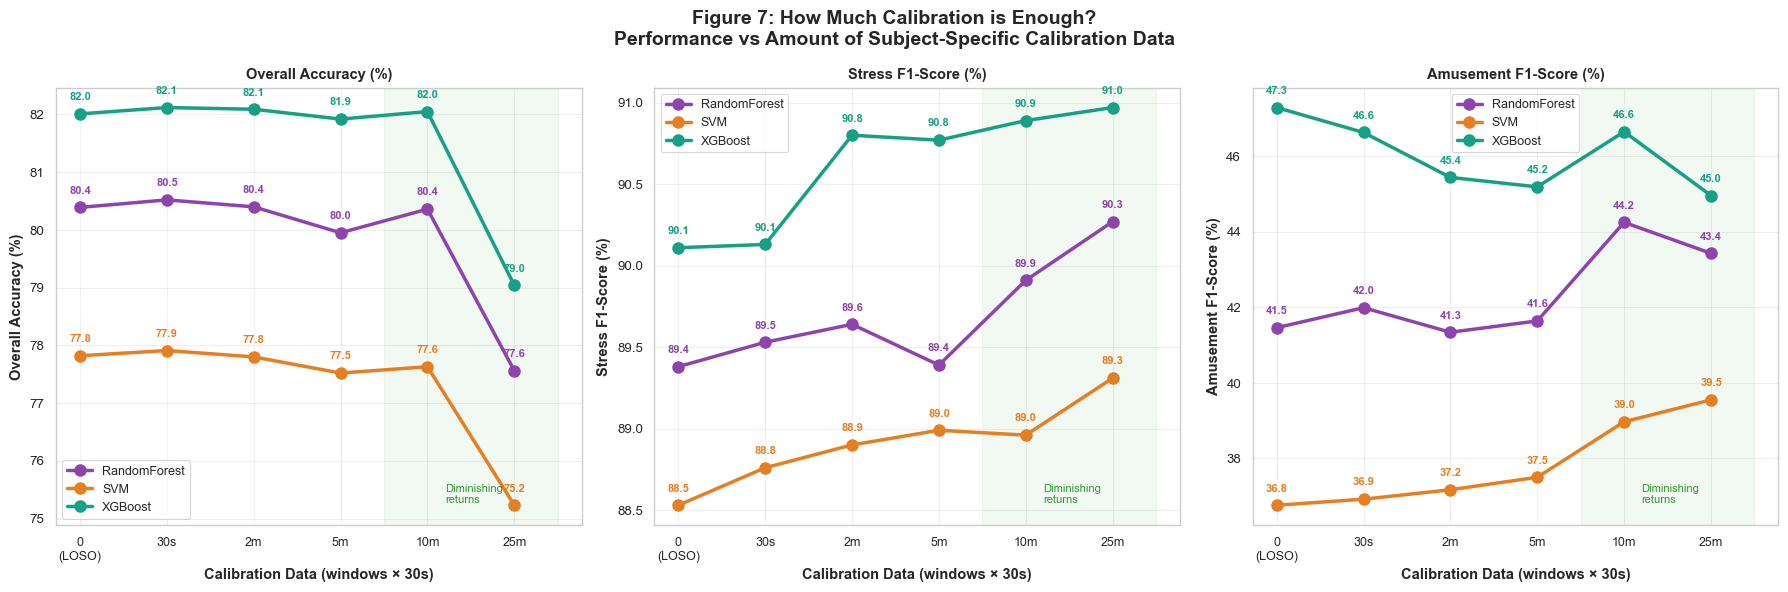

Fig7_Calibration_Curve saved.


In [ ]:
# X axis labels
x_labels = []
for k in K_VALUES:
    secs = k * WINDOW_SEC
    if secs == 0:   x_labels.append('0\n(LOSO)')
    elif secs < 60: x_labels.append(f'{secs}s')
    else:           x_labels.append(f'{secs//60}m')

x_pos   = list(range(len(K_VALUES)))
metrics = [
    ('Accuracy (%)',     'Overall Accuracy (%)'),
    ('Stress F1 (%)',    'Stress F1-Score (%)'),
    ('Amusement F1 (%)', 'Amusement F1-Score (%)')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Figure 7: How Much Calibration is Enough?\n'
    'Performance vs Amount of Subject-Specific Calibration Data',
    fontsize=14, fontweight='bold'
)

for ax, (metric_col, metric_label) in zip(axes, metrics):
    for model_name, color in MODEL_COLORS.items():
        vals = []
        for k in K_VALUES:
            row = calib_df[(calib_df['Model']==model_name) &
                           (calib_df['K (windows)']==k)]
            vals.append(float(row[metric_col].values[0]) if not row.empty else np.nan)

        ax.plot(x_pos, vals, marker='o', linewidth=2.5,
                markersize=8, label=model_name, color=color)

        for x, y in zip(x_pos, vals):
            if not np.isnan(y):
                ax.annotate(f'{y:.1f}', (x, y),
                            textcoords='offset points',
                            xytext=(0, 10), ha='center',
                            fontsize=8, fontweight='bold', color=color)

    # Shade diminishing returns region (after K=10, index 3)
    if len(K_VALUES) > 3:
        ax.axvspan(3.5, len(K_VALUES)-0.5, alpha=0.05, color='green')
        ymin = ax.get_ylim()[0]
        ax.text(4.2, ymin + (ax.get_ylim()[1]-ymin)*0.05,
                'Diminishing\nreturns', fontsize=8,
                color='green', alpha=0.8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_xlabel('Calibration Data (windows × 30s)', fontweight='bold')
    ax.set_ylabel(metric_label, fontweight='bold')
    ax.set_title(metric_label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig7_Calibration_Curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig7_Calibration_Curve saved.")


## Figure 8: Per-Subject Accuracy (K=0 vs Best K)

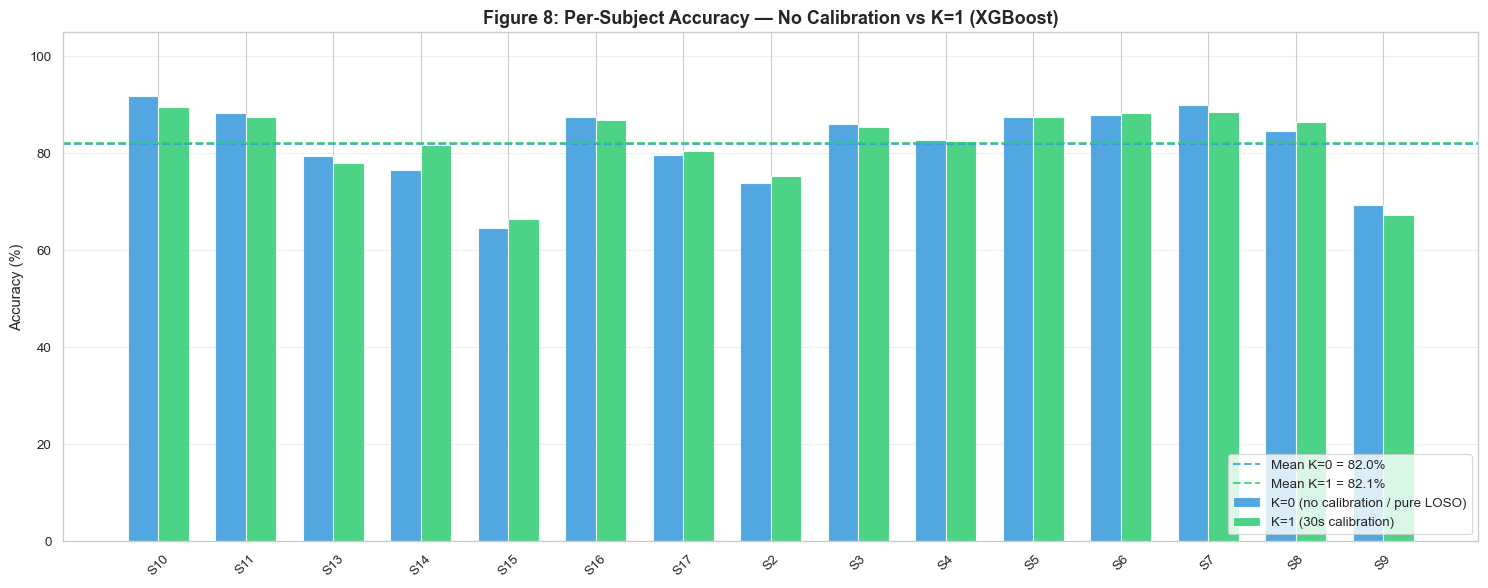

Fig8_PerSubject_Calibration saved.

Subjects that improved    : 6/15
Subjects that got worse   : 9/15
Mean gain from calibration: +0.1%
Max gain (best subject)   : +5.1%
Max loss (worst subject)  : -2.3%


In [ ]:
best_k   = int(calib_df.loc[calib_df['Accuracy (%)'].idxmax(), 'K (windows)'])
best_mdl = calib_df.loc[calib_df['Accuracy (%)'].idxmax(), 'Model']

r_base = CALIB_RESULTS[best_mdl].get(0, {})
r_best = CALIB_RESULTS[best_mdl].get(best_k, {})

if r_base and r_best:
    subj_list = sorted(r_base['per_subject'].keys())
    vals_base = [r_base['per_subject'].get(s, 0) for s in subj_list]
    vals_best = [r_best['per_subject'].get(s, 0) for s in subj_list]

    x = np.arange(len(subj_list)); width = 0.35
    fig, ax = plt.subplots(figsize=(15, 6))

    ax.bar(x - width/2, vals_base, width,
           label='K=0 (no calibration / pure LOSO)',
           color='#3498db', edgecolor='white', alpha=0.85)
    ax.bar(x + width/2, vals_best, width,
           label=f'K={best_k} ({best_k*WINDOW_SEC}s calibration)',
           color='#2ecc71', edgecolor='white', alpha=0.85)

    ax.axhline(np.mean(vals_base), color='#3498db', linestyle='--',
               lw=1.5, alpha=0.8,
               label=f'Mean K=0 = {np.mean(vals_base):.1f}%')
    ax.axhline(np.mean(vals_best), color='#2ecc71', linestyle='--',
               lw=1.5, alpha=0.8,
               label=f'Mean K={best_k} = {np.mean(vals_best):.1f}%')

    ax.set_title(
        f'Figure 8: Per-Subject Accuracy — No Calibration vs '
        f'K={best_k} ({best_mdl})',
        fontsize=13, fontweight='bold'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(subj_list, rotation=45)
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
    ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'Fig8_PerSubject_Calibration.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Fig8_PerSubject_Calibration saved.")

    # Summary stats
    gains = [b - a for a, b in zip(vals_base, vals_best)]
    print(f"\nSubjects that improved    : {sum(g > 0 for g in gains)}/{len(gains)}")
    print(f"Subjects that got worse   : {sum(g < 0 for g in gains)}/{len(gains)}")
    print(f"Mean gain from calibration: +{np.mean(gains):.1f}%")
    print(f"Max gain (best subject)   : +{max(gains):.1f}%")
    print(f"Max loss (worst subject)  : {min(gains):.1f}%")


## Figure 9: Confusion Matrices (K=0 vs Best K)

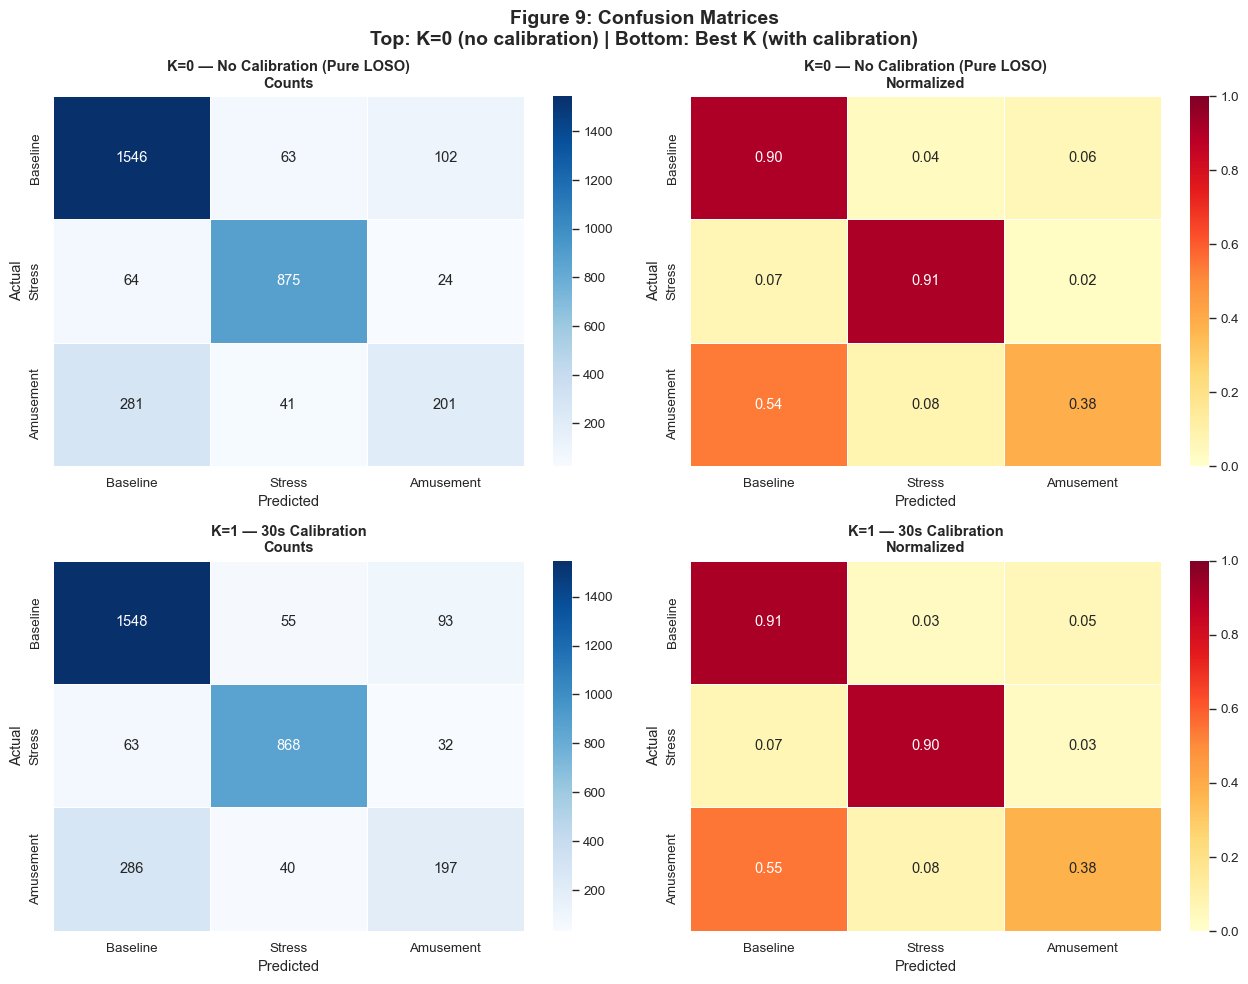

Fig9_Confusion_Matrices saved.


In [ ]:
tick_labels = list(LABEL_MAP.values())
fig, axes   = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Figure 9: Confusion Matrices\n'
             'Top: K=0 (no calibration) | Bottom: Best K (with calibration)',
             fontsize=14, fontweight='bold')

pairs = [
    (best_mdl, 0,      axes[0,0], axes[0,1], 'K=0 — No Calibration (Pure LOSO)'),
    (best_mdl, best_k, axes[1,0], axes[1,1],
     f'K={best_k} — {best_k*WINDOW_SEC}s Calibration'),
]

for mdl, k, ax_raw, ax_norm, title in pairs:
    r = CALIB_RESULTS[mdl].get(k, {})
    if not r: continue
    cm      = confusion_matrix(r['y_true'], r['y_pred'], labels=VALID_LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax_raw, linewidths=0.5)
    ax_raw.set_title(f'{title}\nCounts', fontweight='bold')
    ax_raw.set_ylabel('Actual'); ax_raw.set_xlabel('Predicted')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax_norm, linewidths=0.5, vmin=0, vmax=1)
    ax_norm.set_title(f'{title}\nNormalized', fontweight='bold')
    ax_norm.set_ylabel('Actual'); ax_norm.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig9_Confusion_Matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig9_Confusion_Matrices saved.")


## Figure 10: ROC Curves (K=0 vs Best K)

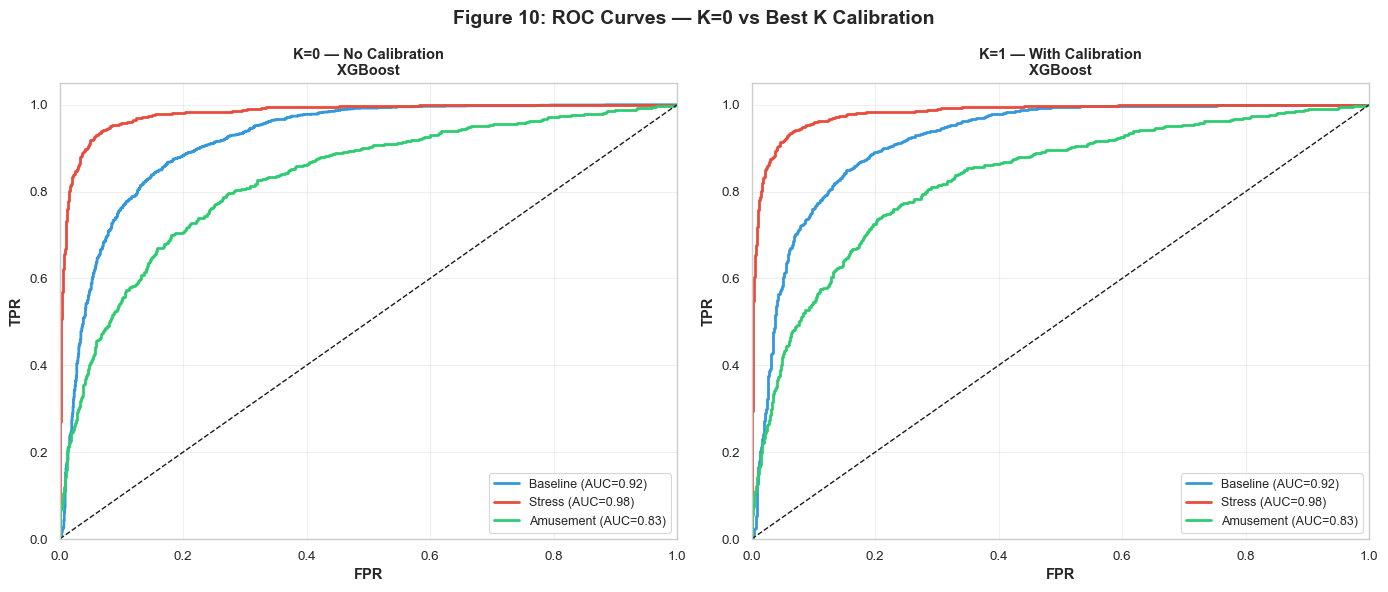

Fig10_ROC_Curves saved.


In [ ]:
class_colors = list(PALETTE.values())
fig, axes    = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 10: ROC Curves — K=0 vs Best K Calibration',
             fontsize=14, fontweight='bold')

for ax, k, title in [(axes[0], 0, f'K=0 — No Calibration'),
                     (axes[1], best_k, f'K={best_k} — With Calibration')]:
    r = CALIB_RESULTS[best_mdl].get(k, {})
    if not r: continue
    y_bin  = label_binarize(r['y_true'], classes=VALID_LABELS)
    y_prob = r['y_prob']
    if y_prob.shape[1] != 3: continue

    for i, (lbl, col) in enumerate(zip(LABEL_MAP.values(), class_colors)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f'{lbl} (AUC={auc(fpr,tpr):.2f})')

    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('FPR', fontweight='bold')
    ax.set_ylabel('TPR', fontweight='bold')
    ax.set_title(f'{title}\n{best_mdl}', fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig10_ROC_Curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig10_ROC_Curves saved.")


## Figure 11: Feature Importance

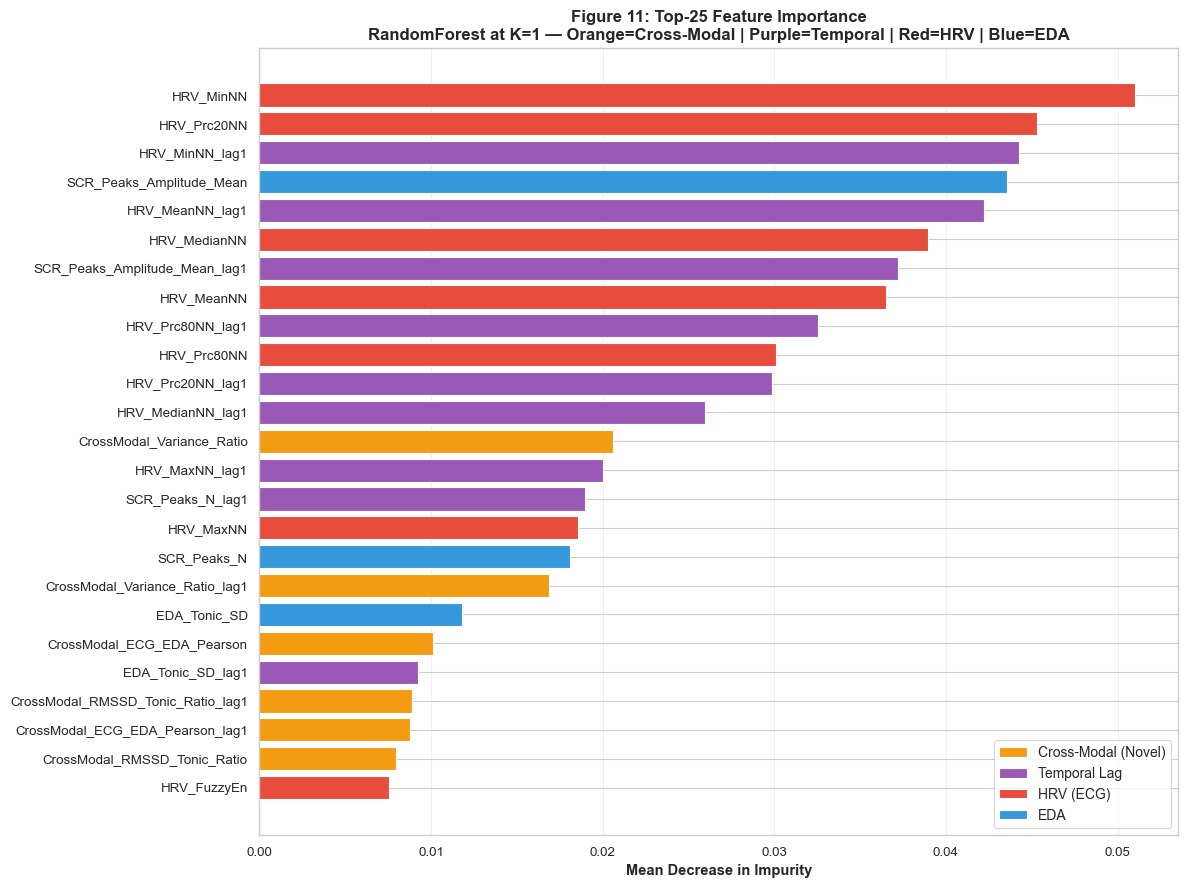

 Fig11_Feature_Importance saved.
 Feature importance CSV has been saved.


In [ ]:
# Use RF at best K for feature importance
r_fi = CALIB_RESULTS['RandomForest'].get(best_k, {})

# Re-run RF once to get feature importances
mod_df_fi, final_cols_fi = prepare_df(CALIB_DF, CALIB_COLS_RAW)

# Collect importances across all LOSO folds
importances_all = []
for test_subj in sorted(mod_df_fi['subject'].unique()):
    other  = mod_df_fi[mod_df_fi['subject'] != test_subj]
    test   = mod_df_fi[mod_df_fi['subject'] == test_subj]
    if other.empty or len(test) < 2: continue

    max_k = max(1, len(test) // 2); actual_k = min(best_k, max_k)
    calib = test.iloc[:actual_k] if best_k > 0 else pd.DataFrame()
    train = pd.concat([other, calib], ignore_index=True) if not calib.empty else other

    X_tr = train[final_cols_fi].copy().replace([np.inf,-np.inf], np.nan)
    X_te = test.iloc[actual_k:][final_cols_fi].copy().replace([np.inf,-np.inf], np.nan)
    y_tr = train['label'].values

    X_te = X_te.fillna(X_tr.median()); X_tr = X_tr.fillna(X_tr.median())
    scaler = StandardScaler()
    clf    = build_models()['RandomForest']
    clf.fit(scaler.fit_transform(X_tr), y_tr)
    importances_all.append(clf.feature_importances_)

if importances_all:
    imp_mean = np.mean(importances_all, axis=0)
    top      = pd.Series(imp_mean, index=final_cols_fi).nlargest(25)

    def feat_color(name):
        if 'CrossModal' in name: return '#f39c12'
        if '_lag1' in name:      return '#9b59b6'
        if 'HRV' in name.upper(): return '#e74c3c'
        return '#3498db'

    colors = [feat_color(f) for f in top.index]
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.barh(top.index, top.values, color=colors, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Mean Decrease in Impurity', fontweight='bold')
    ax.set_title(
        f'Figure 11: Top-25 Feature Importance\n'
        f'RandomForest at K={best_k} — '
        f'Orange=Cross-Modal | Purple=Temporal | Red=HRV | Blue=EDA',
        fontsize=12, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    ax.legend(handles=[
        Patch(facecolor='#f39c12', label='Cross-Modal (Novel)'),
        Patch(facecolor='#9b59b6', label='Temporal Lag'),
        Patch(facecolor='#e74c3c', label='HRV (ECG)'),
        Patch(facecolor='#3498db', label='EDA'),
    ], fontsize=10, loc='lower right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'Fig11_Feature_Importance.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(" Fig11_Feature_Importance saved.")

    pd.DataFrame({'Feature': final_cols_fi, 'Importance': imp_mean,
                  'Type': ['CrossModal' if 'CrossModal' in f else
                           'Temporal' if '_lag1' in f else
                           'HRV' if 'HRV' in f else 'EDA'
                           for f in final_cols_fi]})      .sort_values('Importance', ascending=False)      .to_csv(RESULTS_DIR / 'Feature_Importance.csv', index=False)
    print(" Feature importance CSV has been saved.")


## Statistical Significance (McNemar's Test)

In [ ]:

print("STATISTICAL SIGNIFICANCE — McNemar's Test")
print("K=0 (no calibration) vs Best K (with calibration)")

r_k0   = CALIB_RESULTS[best_mdl].get(0, {})
r_best = CALIB_RESULTS[best_mdl].get(best_k, {})

if r_k0 and r_best:
    y_true  = r_k0['y_true']
    y_pred0 = r_k0['y_pred']
    y_predb = r_best['y_pred']

    min_len = min(len(y_pred0), len(y_predb))
    y_true  = y_true[:min_len]
    y_pred0 = y_pred0[:min_len]
    y_predb = y_predb[:min_len]

    both_correct  = np.sum((y_pred0==y_true) & (y_predb==y_true))
    base_only     = np.sum((y_pred0==y_true) & (y_predb!=y_true))
    calib_only    = np.sum((y_pred0!=y_true) & (y_predb==y_true))
    both_wrong    = np.sum((y_pred0!=y_true) & (y_predb!=y_true))

    table  = [[both_correct, base_only], [calib_only, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)

    print(f"\nContingency Table:")
    print(f"  Both correct          : {both_correct}")
    print(f"  K=0 only correct      : {base_only}")
    print(f"  K={best_k} only correct     : {calib_only}")
    print(f"  Both wrong            : {both_wrong}")

    print(f"\nMcNemar's Test:")
    print(f"  Chi-squared : {result.statistic:.4f}")
    print(f"  p-value     : {result.pvalue:.4f}")

    if result.pvalue < 0.05:
        print(f"\n SIGNIFICANT (p={result.pvalue:.4f} < 0.05)")
        print(f"   Calibration improvement is statistically significant.")
    else:
        print(f"\n  NOT SIGNIFICANT (p={result.pvalue:.4f} >= 0.05)")
        print(f"   Improvement is not statistically significant at p<0.05.")

    pd.DataFrame([{
        'Baseline':    f'K=0 ({best_mdl})',
        'Proposed':    f'K={best_k} ({best_mdl})',
        'Chi_squared': round(result.statistic, 4),
        'p_value':     round(result.pvalue, 4),
        'Significant': result.pvalue < 0.05
    }]).to_csv(RESULTS_DIR / 'McNemar_Test.csv', index=False)
    print(f"\n Saved at: {RESULTS_DIR / 'McNemar_Test.csv'}")


STATISTICAL SIGNIFICANCE — McNemar's Test
K=0 (no calibration) vs Best K (with calibration)

Contingency Table:
  Both correct          : 2173
  K=0 only correct      : 449
  K=1 only correct     : 236
  Both wrong            : 324

McNemar's Test:
  Chi-squared : 65.6117
  p-value     : 0.0000

 SIGNIFICANT (p=0.0000 < 0.05)
   Calibration improvement is statistically significant.

 Saved at: /Users/bsaharmariam/Desktop/wesad_stress_detection/outputs/results/McNemar_Test.csv


## Prior Work Comparison

,Study,Method,Split,Accuracy (%),Note
0,Schmidt et al. 2018,LDA,Subject-dependent,93.00,Original WESAD paper
1,Siirtola 2019,kNN,Subject-dependent,90.20,Personalized model
2,Bobade & Vani 2020,RF,Subject-dependent,88.50,HRV + EDA features
3,Priya et al. 2020,SVM,Subject-dependent,85.30,Time-domain features
4,Can et al. 2019,RF,LOSO,67.50,Wrist sensors only
5,Ours — K=0 (no calib),XGBoost,LOSO,82.01,Pure LOSO baseline
6,Ours — K=1 (proposed),XGBoost,LOSO,82.12,30s calibration


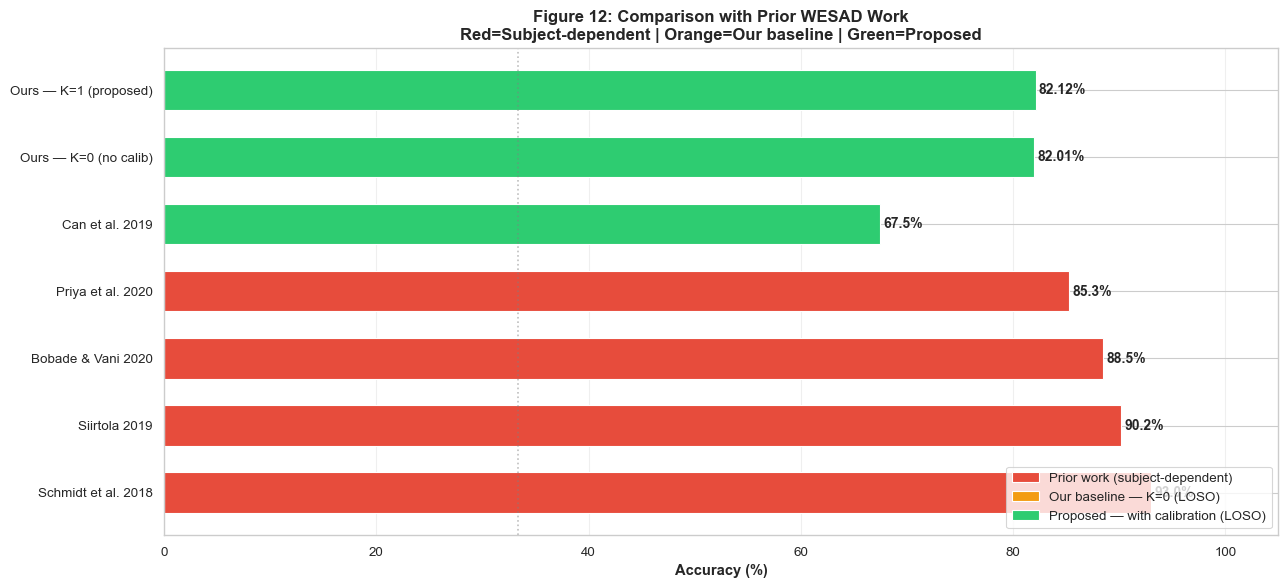

 Fig12_Prior_Work_Comparison saved.


In [ ]:
# Get K=0 and best K accuracy for best model
acc_k0   = calib_df[(calib_df['Model']==best_mdl) &
                    (calib_df['K (windows)']==0)]['Accuracy (%)'].values[0]
acc_best = calib_df[(calib_df['Model']==best_mdl) &
                    (calib_df['K (windows)']==best_k)]['Accuracy (%)'].values[0]

prior_work = pd.DataFrame([
    {'Study': 'Schmidt et al. 2018', 'Method': 'LDA',
     'Split': 'Subject-dependent', 'Accuracy (%)': 93.0,
     'Note': 'Original WESAD paper'},
    {'Study': 'Siirtola 2019', 'Method': 'kNN',
     'Split': 'Subject-dependent', 'Accuracy (%)': 90.2,
     'Note': 'Personalized model'},
    {'Study': 'Bobade & Vani 2020', 'Method': 'RF',
     'Split': 'Subject-dependent', 'Accuracy (%)': 88.5,
     'Note': 'HRV + EDA features'},
    {'Study': 'Priya et al. 2020', 'Method': 'SVM',
     'Split': 'Subject-dependent', 'Accuracy (%)': 85.3,
     'Note': 'Time-domain features'},
    {'Study': 'Can et al. 2019', 'Method': 'RF',
     'Split': 'LOSO', 'Accuracy (%)': 67.5,
     'Note': 'Wrist sensors only'},
    {'Study': f'Ours — K=0 (no calib)', 'Method': best_mdl,
     'Split': 'LOSO', 'Accuracy (%)': acc_k0,
     'Note': 'Pure LOSO baseline'},
    {'Study': f'Ours — K={best_k} (proposed)', 'Method': best_mdl,
     'Split': 'LOSO', 'Accuracy (%)': acc_best,
     'Note': f'{best_k*WINDOW_SEC}s calibration'},
])

prior_work.to_csv(RESULTS_DIR / 'Prior_Work_Comparison.csv', index=False)
display(prior_work)

# Figure
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#e74c3c' if 'Subject-dependent' in s else
          '#f39c12' if 'K=0' in s else
          '#2ecc71'
          for s in prior_work['Split']]

bars = ax.barh(prior_work['Study'],
               prior_work['Accuracy (%)'].astype(float),
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, prior_work['Accuracy (%)'].astype(float)):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(33.3, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_title('Figure 12: Comparison with Prior WESAD Work\n'
             'Red=Subject-dependent | Orange=Our baseline | Green=Proposed',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Prior work (subject-dependent)'),
    Patch(facecolor='#f39c12', label='Our baseline — K=0 (LOSO)'),
    Patch(facecolor='#2ecc71', label='Proposed — with calibration (LOSO)'),
], loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Fig12_Prior_Work_Comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(" Fig12_Prior_Work_Comparison saved.")


## Export & Final Summary

In [ ]:
# Export all classification reports
for model_name in build_models():
    for k in K_VALUES:
        r = CALIB_RESULTS[model_name].get(k, {})
        if not r: continue
        r_df = pd.DataFrame(r['report']).transpose()
        r_df['precision_%'] = (r_df['precision']*100).round(2)
        r_df['recall_%']    = (r_df['recall']*100).round(2)
        r_df['f1-score_%']  = (r_df['f1-score']*100).round(2)
        fname = f'Report_{model_name}_K{k}.csv'
        r_df.round(4).to_csv(RESULTS_DIR / fname, index=True)

print("Final Summary: Calibration Study")

# Key findings table
print("\nAccuracy at each K value (best model per K):")
summary = calib_df.loc[calib_df.groupby('K (windows)')['Accuracy (%)'].idxmax()]
display(summary[['K (windows)','Calibration Time','Model',
                 'Accuracy (%)',"Cohen's Kappa",
                 'Stress F1 (%)','Amusement F1 (%)']])

best_row = calib_df.loc[calib_df['Accuracy (%)'].idxmax()]
base_row = calib_df[(calib_df['Model']==best_mdl) &
                    (calib_df['K (windows)']==0)].iloc[0]

print(f"\n Findings:")
print(f"   No calibration (K=0)  : {base_row['Accuracy (%)']}% accuracy")
print(f"   Best calibration K={best_k} : {best_row['Accuracy (%)']}% accuracy")
print(f"   Improvement           : +{best_row['Accuracy (%)']-base_row['Accuracy (%)']:.2f}%")
print(f"   Calibration time      : {best_row['Calibration Time']}")
print(f"   Model                 : {best_row['Model']}")

print("\n Figures saved:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}")
print("\nResults saved:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    print(f"  {f.name}")
print(f"\n Complete! — All outputs in {BASE_DIR / 'outputs'}")


Final Summary: Calibration Study

Accuracy at each K value (best model per K):


,K (windows),Calibration Time,Model,Accuracy (%),Cohen's Kappa,Stress F1 (%),Amusement F1 (%)
12,0,None (LOSO),XGBoost,82.01,0.687,90.11,47.29
13,1,30s,XGBoost,82.12,0.688,90.13,46.63
14,5,2m 30s,XGBoost,82.09,0.689,90.80,45.44
15,10,5m 0s,XGBoost,81.92,0.688,90.77,45.19
16,20,10m 0s,XGBoost,82.05,0.696,90.89,46.65
17,50,25m 0s,XGBoost,79.04,0.663,90.97,44.96



 Findings:
   No calibration (K=0)  : 82.01% accuracy
   Best calibration K=1 : 82.12% accuracy
   Improvement           : +0.11%
   Calibration time      : 30s
   Model                 : XGBoost

 Figures saved:
  Fig10_PR_Curves.png
  Fig10_ROC_Curves.png
  Fig11_Feature_Importance.png
  Fig12_PerSubject_Accuracy.png
  Fig12_Prior_Work_Comparison.png
  Fig13_Temporal_Tracking.png
  Fig1_Preprocessing_QC.png
  Fig2_EDA_Decomposition.png
  Fig3_Label_Distribution.png
  Fig4_Feature_Boxplots.png
  Fig5_Correlation_Heatmap.png
  Fig5_CrossModal_Boxplots.png
  Fig6_Correlation_Heatmap.png
  Fig6_Statistical_Significance.png
  Fig7_Calibration_Curve.png
  Fig7_Model_Comparison.png
  Fig7_Statistical_Significance.png
  Fig8_Confusion_Matrices.png
  Fig8_PerSubject_Calibration.png
  Fig9_Confusion_Matrices.png
  Fig9_ROC_Curves.png

Results saved:
  Calibration_Results.csv
  Feature_Importance.csv
  Feature_Importance_ECG_Only.csv
  Feature_Importance_EDA_Only.csv
  Feature_Importance_Fusio